First we import the library, forcing reload from local version (not pip install). 

In [1]:
import os
import sys
import importlib
import matplotlib.pyplot as plt


# Get the absolute path to the directory containing the local module
stlrom_path = os.path.abspath('../build')
print(stlrom_path)

# Insert the local module path at the beginning of sys.path
sys.path.insert(0, stlrom_path)

import stlrom

# Reload the module to ensure it is loaded from the new path
importlib.reload(stlrom)

import stlrom as sr
import numpy as np

print(sr.Signal.get_interpol())


/home/dayekhh/Documents/git-repos/stlrom2/build
LINEAR


# Signals


## Function


In [2]:
import matplotlib.pyplot as plt

# Plotting
def plot_signal(signal,label=None, fig=None):
    samples_list = signal.get_samples_list()

    if fig is None:
        fig = plt.figure(figsize=(15, 5)).gca()

    if label is None:
        label = f'Signal {len(fig.get_lines()) + 1}'

    fig.set_xlabel('Time')
    fig.set_ylabel('Value')
    fig.set_title('Signal Plot')
    fig.grid(True)
        
    def plot_sample(s, dt, color=None):
        if color is None:
            l, = fig.plot(s.time, s.value, marker='o')
            color = l.get_color()
            l = fig.plot([s.time, s.time+dt], [s.value, s.value_at(s.time+dt)], color=color, linestyle='-')
        else:
            l = fig.plot(s.time, s.value, marker='o', color=color)
            l = fig.plot([s.time, s.time+dt], [s.value, s.value_at(s.time+dt)], color=color, linestyle='-')
        return color,l
    
    if len(samples_list) > 1:
        s = samples_list[0]
        sn = samples_list[1]
        dt = sn.time-s.time
            
        col,l = plot_sample(s, dt)
        
        
        for i in range(1, len(samples_list)-1):
            s = samples_list[i]
            sn = samples_list[i+1]
            dt = sn.time-s.time
            plot_sample(s,dt,color=col)
    else:
        sn = samples_list[0]
        col = None
    
    col, l = plot_sample(sn, signal.end_time-sn.time, col)
    l[0].set_label(label)
    #fig.plot(sn.time, sn.value, marker='o', color=col)
    fig.legend()
    fig.figure.canvas.draw()

    return fig

# Printing
def print_signal(signal):
    for s in signal.get_samples_list():
        s.print_sample()
    print('begin_time ', signal.begin_time)
    print('end_time    ',signal.end_time)



## Test signals

### Basic test signals

In [3]:
# One sample
sig0 = sr.Signal()
sig0.append_sample(0, -1)
sig0.append_sample(1., 1)

sig1 = sr.Signal()
sig1.append_sample(.3, 2)
sig1.append_sample(.6, 1.5)
sig1.append_sample(1.3, -3)



### Longer signals

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

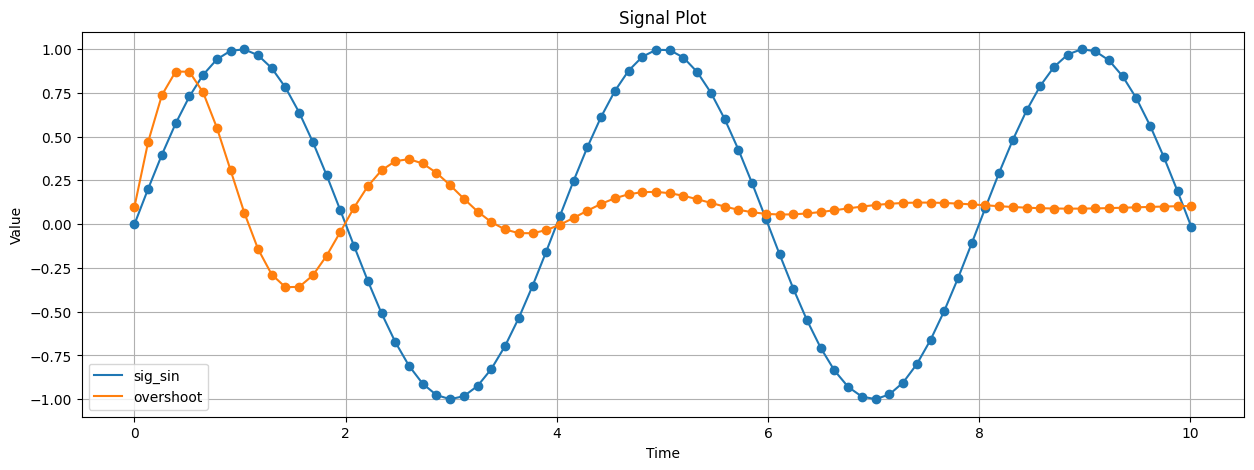

In [4]:
times = np.arange(0, 10.1, .13)
sin_val = np.sin(times*np.pi/2)
overshoot_val = np.sin(times*np.pi*np.exp(-times/50))*np.exp(-times/2)+.1
sig_sin = sr.Signal()
sig_overshoot = sr.Signal()

for i in range(0,len(times)):
    sig_sin.append_sample(times[i],sin_val[i])
    sig_overshoot.append_sample(times[i],overshoot_val[i])

fig= plot_signal(sig_sin, 'sig_sin')
plot_signal(sig_overshoot, 'overshoot', fig)


# Testing monitors


In [5]:
stl_parser = stlrom.STLDriver()
stl_parser.parse_string("""signal x, y       # declaring signals named 'x' and 'y'
param p=0.2, tau=5  # declaring parameters named 'p' and 'q'
# Let's add some formulas
mu_x := x[t] > p
mu_less := x[t] < p
mu_eq := x[t] == p 
mu_neq := not mu_eq
mu_or := mu_x or mu_less
phi_x := ev_[0, tau] ( mu_x )
mu_y := y[t] < p 
mu := mu_x and mu_y 
phi_y := y[t]>p => ev_[0, tau] (y[t]<p)
""")


True

In [6]:
# Helper, to add data to a monitor
def add_signals(mon,times, sig_x, sig_y):
    for i in range(0, len(times)):
        mon.add_sample([times[i],sig_x[i],sig_y[i]])
    return mon


Monitoring phi_x

In [7]:
phi_x = stl_parser.get_monitor("phi_x")
phi_x_ltr = stl_parser.get_monitor("phi_x")

phi_x = add_signals(phi_x, times, sin_val, overshoot_val)
phi_x_ltr = add_signals(phi_x_ltr, times, sin_val, overshoot_val)



In [8]:
phi_x.data

[[0.0, 0.0, 0.1],
 [0.13, 0.2027872953565125, 0.4712421474671936],
 [0.26, 0.3971478906347806, 0.7375517889420248],
 [0.39, 0.5750052520432786, 0.8715009273722759],
 [0.52, 0.7289686274214116, 0.8702384313823974],
 [0.65, 0.8526401643540922, 0.7522031110647444],
 [0.78, 0.9408807689542255, 0.5510446485138395],
 [0.91, 0.9900236577165575, 0.308169716591943],
 [1.04, 0.9980267284282716, 0.06529577262372466],
 [1.17, 0.9645574184577982, -0.1418495671837031],
 [1.3, 0.8910065241883679, -0.28792154100905765],
 [1.4300000000000002, 0.7804304073383297, -0.3601053115313738],
 [1.56, 0.6374239897486899, -0.35807597470735897],
 [1.69, 0.4679298142605734, -0.292145661778789],
 [1.82, 0.2789911060392291, -0.18017332021256885],
 [1.9500000000000002, 0.07845909572784462, -0.04389203068389233],
 [2.08, -0.12533323356430429, 0.09472250634901483],
 [2.21, -0.3239174181981492, 0.21653463036588416],
 [2.34, -0.5090414157503709, 0.3074423994418751],
 [2.47, -0.6730125135097734, 0.35952726995585305],
 [2.6

In [9]:
phi_x_ltr.set_semantics("LEFT_TIME")

print(phi_x.get_semantics())
print(phi_x_ltr.get_semantics())

SPACE
LEFT_TIME


In [10]:
phi_x.set_eval_time(0,5)
phi_x.eval_rob()

0.7980267284282716

In [11]:
print_signal(phi_x.get_signal())

begin_time  0.0
end_time     5.0
Time 0.00000 Value 0.79803 Derivative 0.00000
Time 1.04000 Value 0.79803 Derivative -0.25746
Time 1.04957 Value 0.79556 Derivative 0.00000
Time 3.95572 Value 0.79556 Derivative 0.23313
Time 3.97000 Value 0.79889 Derivative 0.00000


## Some plots

In [12]:
mu_x = stl_parser.get_monitor("mu_x")
print(mu_x.data)
mu_x = add_signals(mu_x, times, sin_val, overshoot_val)
print(mu_x.data)

mu_eq = stl_parser.get_monitor("mu_eq")
mu_eq = add_signals(mu_eq, times, sin_val, overshoot_val)

mu_less = stl_parser.get_monitor("mu_less")
mu_less = add_signals(mu_less, times, sin_val, overshoot_val)

mu_or = stl_parser.get_monitor("mu_or")
mu_or = add_signals(mu_or, times, sin_val, overshoot_val)

[]
[[0.0, 0.0, 0.1], [0.13, 0.2027872953565125, 0.4712421474671936], [0.26, 0.3971478906347806, 0.7375517889420248], [0.39, 0.5750052520432786, 0.8715009273722759], [0.52, 0.7289686274214116, 0.8702384313823974], [0.65, 0.8526401643540922, 0.7522031110647444], [0.78, 0.9408807689542255, 0.5510446485138395], [0.91, 0.9900236577165575, 0.308169716591943], [1.04, 0.9980267284282716, 0.06529577262372466], [1.17, 0.9645574184577982, -0.1418495671837031], [1.3, 0.8910065241883679, -0.28792154100905765], [1.4300000000000002, 0.7804304073383297, -0.3601053115313738], [1.56, 0.6374239897486899, -0.35807597470735897], [1.69, 0.4679298142605734, -0.292145661778789], [1.82, 0.2789911060392291, -0.18017332021256885], [1.9500000000000002, 0.07845909572784462, -0.04389203068389233], [2.08, -0.12533323356430429, 0.09472250634901483], [2.21, -0.3239174181981492, 0.21653463036588416], [2.34, -0.5090414157503709, 0.3074423994418751], [2.47, -0.6730125135097734, 0.35952726995585305], [2.6, -0.809016994374

interpol:LINEAR
interpol:LINEAR
interpol:LINEAR


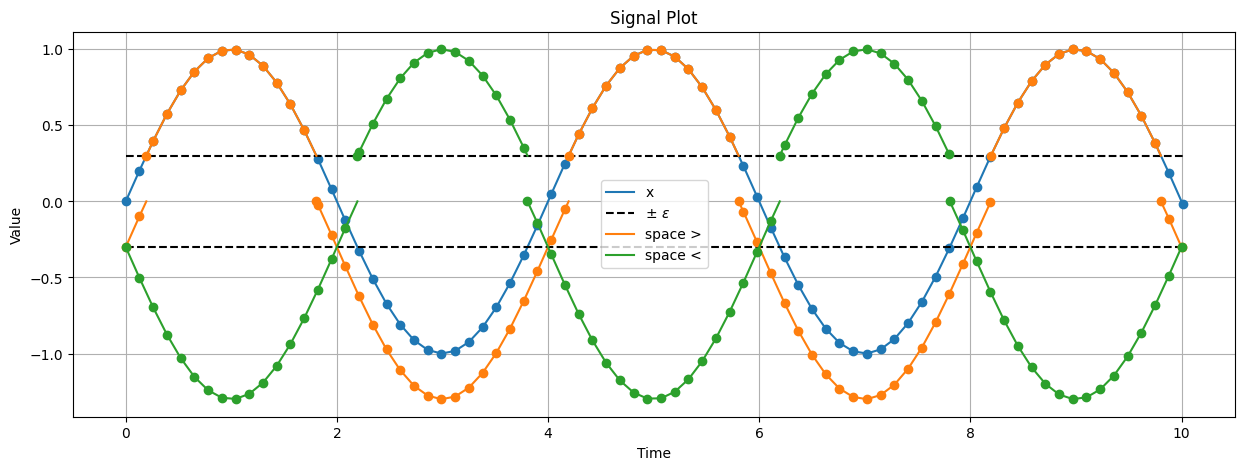

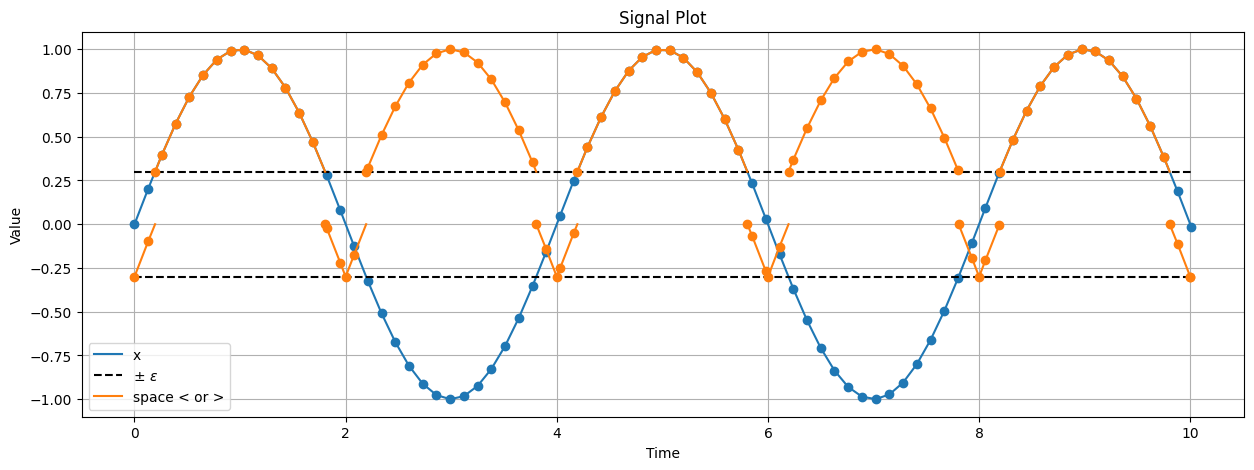

In [21]:
stlrom.Signal.set_BigM(2)
stlrom.Signal.set_Eps(0.3)

mu_x.set_eval_time(0, 10) 
mu_eq.set_eval_time(0, 10)
mu_less.set_eval_time(0, 10)
mu_or.set_eval_time(0, 10)


mu_x.set_param("p", 0)
mu_eq.set_param("p", 0)
mu_less.set_param("p", 0)
mu_or.set_param("p", 0)


interp = "LINEAR"

fig = sig_sin.plot(label="x")

fig.plot([0, sig_sin.end_time], [stlrom.Signal.get_Eps(), stlrom.Signal.get_Eps()], linestyle='--', color='black', label="± $\\varepsilon$")
fig.plot([0, sig_sin.end_time], [-stlrom.Signal.get_Eps(), -stlrom.Signal.get_Eps()], linestyle='--', color='black')

mu_x.set_semantics("SPACE")
mu_x.set_interpol(interp)
mu_x.eval_rob()
z_space = mu_x.get_signal()
fig = z_space.plot(label="space >", fig=fig)



# mu_eq.set_semantics("BOOLEAN")
# mu_eq.set_interpol(interp)
# mu_eq.eval_rob()
# z_bool = mu_eq.get_signal()
# fig = z_bool.plot(label="bool =", fig=fig)


# mu_eq.set_semantics("SPACE")
# mu_eq.set_interpol(interp)
# mu_eq.eval_rob()
# z_space_eq = mu_eq.get_signal()
# fig = z_space_eq.plot(label="space =", fig=fig)


mu_less.set_semantics("SPACE")
mu_less.set_interpol(interp)
mu_less.eval_rob()
z_space_less = mu_less.get_signal()
fig = z_space_less.plot(label="space <", fig=fig)



# mu_x.set_semantics("LEFT_TIME")
# mu_x.eval_rob()
# z_space = mu_x.get_signal()
# plot_signal(z_space, label="ltr", fig=fig)

# mu_x.set_semantics("RIGHT_TIME")
# mu_x.eval_rob()
# z_space = mu_x.get_signal()
# plot_signal(z_space, label="rtr", fig=fig)

# mu_x.set_semantics("BOOLEAN")
# mu_x.eval_rob()
# z_space = mu_x.get_signal()
# plot_signal(z_space, label="boolean", fig=fig)


fig = sig_sin.plot(label="x")

fig.plot([0, sig_sin.end_time], [stlrom.Signal.get_Eps(), stlrom.Signal.get_Eps()], linestyle='--', color='black', label="± $\\varepsilon$")
fig.plot([0, sig_sin.end_time], [-stlrom.Signal.get_Eps(), -stlrom.Signal.get_Eps()], linestyle='--', color='black')



mu_or.set_semantics("SPACE")
mu_or.set_interpol(interp)
mu_or.eval_rob()
z_space_or = mu_or.get_signal()
fig = z_space_or.plot(label="space < or >", fig=fig)

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

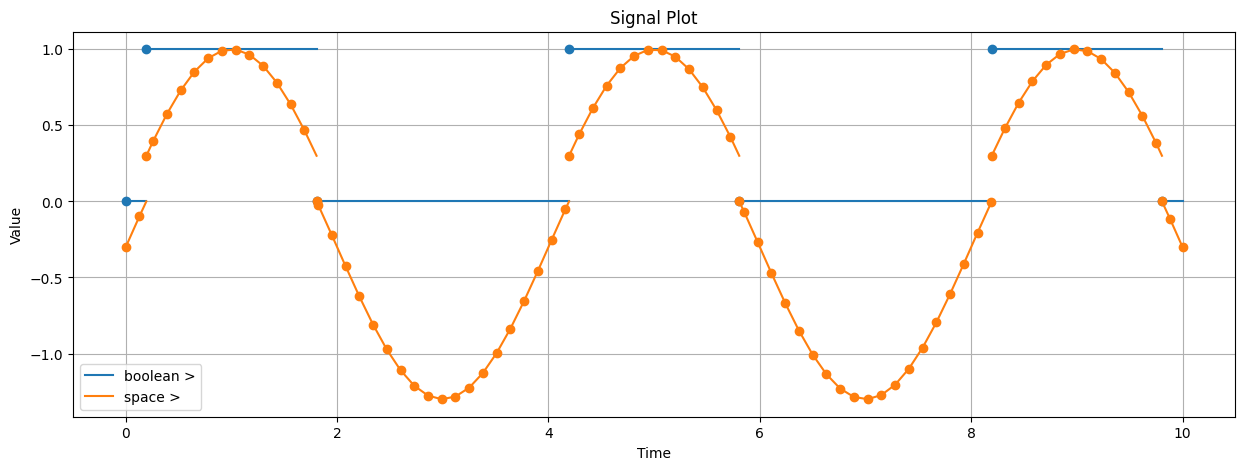

In [14]:
mu_x.set_semantics("BOOLEAN")
mu_x.eval_rob()
z_boolean_x = mu_x.get_signal()
fig2 = z_boolean_x.plot(label="boolean >")

mu_x.set_semantics("SPACE")
mu_x.eval_rob()
z_boolean_x = mu_x.get_signal()
z_boolean_x.plot(label="space >", fig=fig2)

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

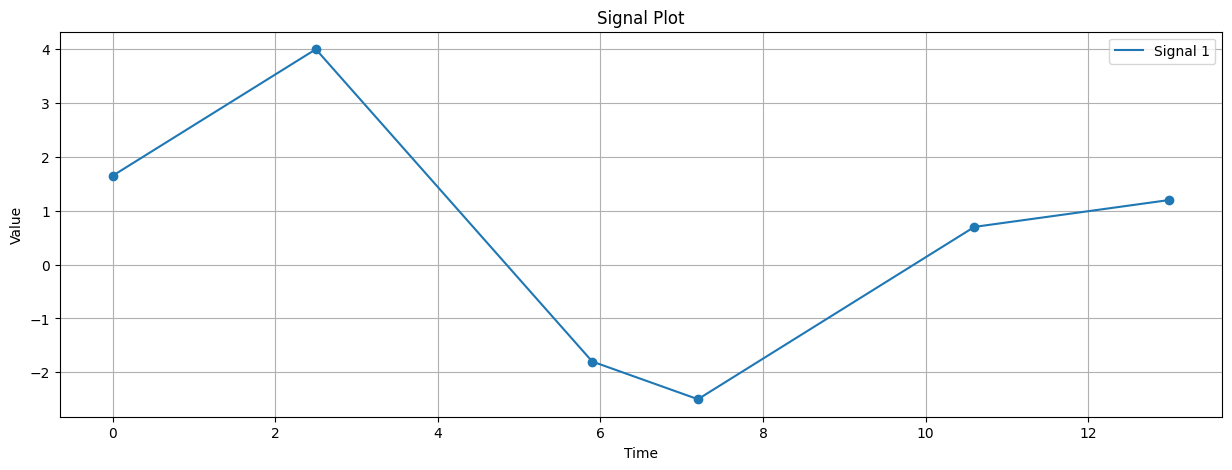

In [15]:

sig_test = sr.Signal()


times = np.array([0, 2.5, 5.9, 7.2, 10.6, 13])
sig_test_samples = np.array([1.65, 4., -1.8, -2.5, .7, 1.2]
)
for t, x in zip(times, sig_test_samples):
    sig_test.append_sample(t, x)

sig_test.plot()


interpol:LINEAR
interpol:LINEAR
begin_time  0.0
end_time     13.0
Time 0.00000 Value -1.65000 Derivative -0.94000
Time 2.50000 Value -4.00000 Derivative 1.70588
Time 4.31724 Value 6.00000 Derivative 0.00000
Time 5.37241 Value -0.90000 Derivative -1.70588
Time 5.90000 Value -1.80000 Derivative -0.53846
Time 7.20000 Value -2.50000 Derivative 0.94118
Time 8.90000 Value 6.00000 Derivative 0.00000
Time 11.56000 Value -0.90000 Derivative -0.20833
Time 13.00000 Value -1.20000 Derivative 0.00000


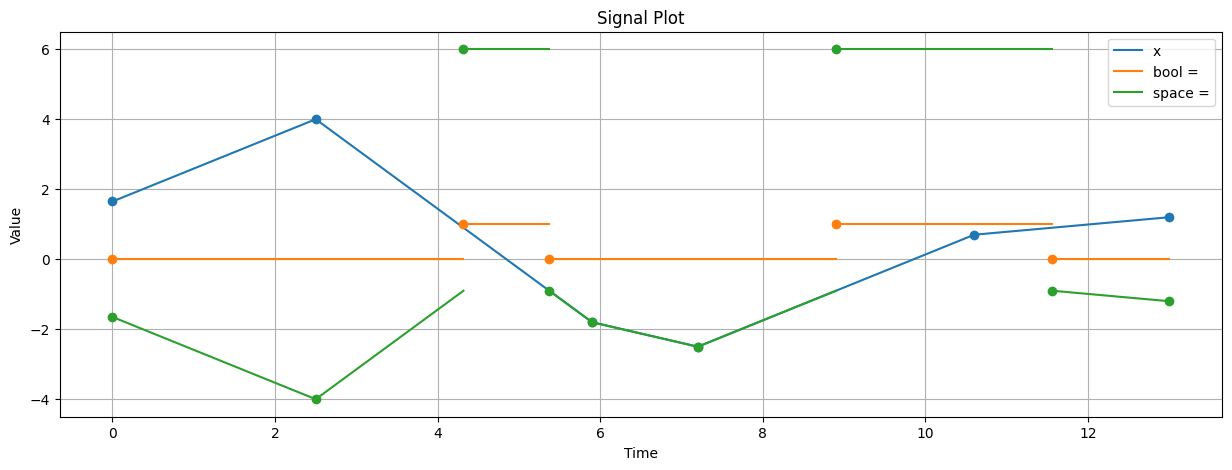

In [16]:
sr.Signal.set_Eps(.9)
sr.Signal.set_BigM(6)

mu_eq2 = stl_parser.get_monitor("mu_eq")
mu_eq2 = add_signals(mu_eq2, times, sig_test_samples, sig_test_samples)
mu_eq2.set_eval_time(0,times[-1])
mu_eq2.set_param("p", 0)

fig = sig_test.plot(label="x")


mu_eq2.set_semantics("BOOLEAN")
mu_eq2.set_interpol(interp)
mu_eq2.eval_rob()
z_bool = mu_eq2.get_signal()
fig = z_bool.plot(label="bool =", fig=fig)


mu_eq2.set_semantics("SPACE")
mu_eq2.set_interpol(interp)
mu_eq2.eval_rob()
z_space_eq2 = mu_eq2.get_signal()
fig = z_space_eq2.plot(label="space =", fig=fig)

print_signal(z_space_eq2)

In [17]:
mu_x.set_eval_time(0, 10) 
ev_x.set_eval_time(0,6)
mu_x.set_param('p', .3)
ev_x.set_param('p', .3)

mu_x.eval_robustness()
rho_mu_x = mu_x.get_signal()
ev_x.eval_robustness()
rho_ev_x = ev_x.get_signal()


fig = plot_signal(rho_mu_x, 'mu_x')
plot_signal(rho_ev_x, 'rho(ev_x)', fig)


NameError: name 'ev_x' is not defined

In [ ]:

print_signal(rho_ev_x)

In [ ]:
ev_x